#Descriptive Statistics using PYTHON

Descriptive statistics is a branch of statistics that deals with summarizing, organizing, and presenting data in a meaningful and informative way.

The Two Main Categories of Descriptive Statistics
Descriptive statistics is primarily broken down into two components: Measures of Central Tendency and Measures of Variability (or Dispersion).

1. Measures of Central Tendency

These statistics describe the center point or typical value of a distribution. They answer the question: "What is the most typical score?"

| Statistic | Definition| Purpose|
| --- | --- | --- |
| Mean | The arithmetic average; the sum of all values divided by the number of values. | Best for normally distributed data; sensitive to outliers. |
|Median | The middle value when the data is ordered from least to greatest. | Best for skewed data or data with extreme outliers. |
| Mode | The value that appears most frequently in a dataset.| Best for categorical or nominal data.|

2. Measures of Variability (or Dispersion)

These statistics describe the spread or how far apart the data points are from the center. They answer the question: "How varied or dispersed are the scores?"

| Statistic | Definition | Purpose |
| --- | --- | --- |
| Range | The difference between the highest and lowest values in a dataset. |  "Provides a quick, rough estimate of spread."|
| Variance |The average of the squared differences from the Mean. | Used as an intermediate step to calculate standard deviation.|
| Standard Deviation | The square root of the variance. It measures the average amount of variability in the dataset. | The most common measure of spread; expressed in the original data units.|
|Coefficient of Variation | Coefficient of Variation (CV) is equal to the standard deviation divided by the mean| provide a unit-less measure of risk or uncertainty relative to the expected value.|
| Interquartile Range (IQR) | The difference between the 75th percentile (Q3) and the 25th percentile (Q1).| "Excellent for describing spread when data is skewed or contains outliers as it focuses on the middle 50% of the data."|

3. The Measures of Shape

The measure of shape are descriptive statistics that quantify how the data is distributed around its mean. They describe the qualitative appearance of a frequency distribution or a histogram.

The two primary measures of shape are Skewness and Kurtosis.

***Skewness***

Skewness measures the asymmetry of a probability distribution. It tells you the direction and extent to which a dataset deviates from the symmetrical "bell-shaped" normal distribution.

| Type of Skew | Description | Skewness Value |Implication |
| --- | --- | --- | --- |
|Zero Skew / Symmetric |"The left and right sides of the distribution are mirror images. Mean, Median, and Mode are approximately equal." | Close to 0 | Data is likely normally distributed.|
| Positive Skew (Right-Skewed) | The tail of the distribution is longer on the right side. The Mean is greater than the Median. | "Greater than 0 (e.g., 0.5, 1.0)" | "Many small values, with a few extremely large outliers pulling the mean to the right. (e.g., income data)." |
| Negative Skew (Left-Skewed) | The tail of the distribution is longer on the left side. The Mean is less than the Median. | "Less than 0 (e.g., −0.5, −1.0)" |"Many large values, with a few extremely small outliers pulling the mean to the left. (e.g., exam scores)."|

***Kurtosis***

Kurtosis measures the "tailedness" of the distribution—specifically, it describes the extremity of the tails (the frequency of outliers) and the peakedness of the curve.

| Type of Kurtosis | Description | Kurtosis Value (Excess Kurtosis) | Implication |
| --- | --- | --- | --- |
|Mesokurtic | A distribution with tails and peakedness similar to a normal distribution. | Close to 0 | Standard variance is explained by the distribution.|
|Leptokurtic | "High peak and heavy, fat tails. More data falls into the extreme values (outliers) than a normal distribution." | Greater than 0 | High probability of extreme outcomes or rare events (high risk).|
| Platykurtic |"Flat peak and light, thin tails. Less data falls into the extreme values than a normal distribution." | Less than 0 | Low probability of extreme outcomes.|


## Descriptive Analysis
We shall be computing descriptive analysis on The Auto MPG dataset - the dataset (from UCI / seaborn) contains fuel efficiency and engine characteristics for various car models manufactured between 1970 and 1982.

Dataset Dimension:
| Column       | Type         | Description                                       |
| ------------ | ------------ | ------------------------------------------------- |
| mpg          | float        | Miles per gallon (target variable)                |
| cylinders    | int          | Number of cylinders                               |
| displacement | float        | Engine displacement (cu inches)                   |
| horsepower   | float/string | Engine horsepower (contains “?” converted to NaN) |
| weight       | float        | Vehicle weight (lbs)                              |
| acceleration | float        | 0–60 mph acceleration time                        |
| model_year   | int          | Model year (70-82)                                |
| origin       | category     | Region of origin: USA, Europe, Japan              |
| name         | object       | Car model name                                    |


In [48]:
# Installing libraries
import numpy as np
import seaborn as sns
import sklearn
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression

In [49]:
# Load Data and Read data
df=pd.read_csv('mpg.csv')
# Understand Data Shape
print(df.shape)
df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [50]:
#Evaluate Numerical and Categorical data in dataset
cats = list(df.select_dtypes(include=['object']).columns)
nums = list(df.select_dtypes(exclude=['object']).columns)
print(f'categorical variables:  {cats}')
print(f'numerical variables:  {nums}')

categorical variables:  ['horsepower', 'car name']
numerical variables:  ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']


In [51]:
# cylinders and model_year also seems to be categorical so lets update the lists
# Add 'cylinders' and 'model_year' to the categorical list
cats.extend(['cylinders', 'model year'])

# Remove 'cylinders' and 'model_year' from the numerical list
# Use a try-except block in real scenarios to handle cases where a variable might already be missing
try:
    nums.remove('cylinders')
    nums.remove('model year')
except ValueError as e:
    # This happens if 'cylinders' or 'model_year' was not in 'nums' to begin with
    print(f"Warning: Could not remove a key from 'nums'. Error: {e}")

# Print the updated lists
print(f'Categorical variables: {cats}')
print(f'Numerical variables: {nums}')

Categorical variables: ['horsepower', 'car name', 'cylinders', 'model year']
Numerical variables: ['mpg', 'displacement', 'weight', 'acceleration', 'origin']


In [52]:
# check for `nans` in each column
df.isna().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [53]:
# for now remove all nan rows as they are just 1.5%
df = df[~df.isnull().any(axis=1)]
df.reset_index(inplace=True)
df.drop('index', inplace=True, axis=1)
df.shape

(398, 9)

In [54]:
# find total duplicate entries and drop them if any
print(f'total duplicate rows: {df.duplicated().sum()}')

# drop duplicate rows if any
df = df[~df.duplicated()]
df.shape

total duplicate rows: 0


(398, 9)

In [55]:
# before we move ahead it's a good practice to group all variables together having same type.
df = pd.concat((df[cats], df[nums]), axis=1)
df.head()

,horsepower,car name,cylinders,model year,mpg,displacement,weight,acceleration,origin
0,130,chevrolet chevelle malibu,8,70,18.0,307.0,3504,12.0,1
1,165,buick skylark 320,8,70,15.0,350.0,3693,11.5,1
2,150,plymouth satellite,8,70,18.0,318.0,3436,11.0,1
3,150,amc rebel sst,8,70,16.0,304.0,3433,12.0,1
4,140,ford torino,8,70,17.0,302.0,3449,10.5,1


In [56]:
# Extract Descriptive Statistics for numerical variables
descriptive_stats = df.describe()

# Display the descriptive statistics
print(descriptive_stats)

        cylinders  model year         mpg  displacement       weight  \
count  398.000000  398.000000  398.000000    398.000000   398.000000   
mean     5.454774   76.010050   23.514573    193.425879  2970.424623   
std      1.701004    3.697627    7.815984    104.269838   846.841774   
min      3.000000   70.000000    9.000000     68.000000  1613.000000   
25%      4.000000   73.000000   17.500000    104.250000  2223.750000   
50%      4.000000   76.000000   23.000000    148.500000  2803.500000   
75%      8.000000   79.000000   29.000000    262.000000  3608.000000   
max      8.000000   82.000000   46.600000    455.000000  5140.000000   

       acceleration      origin  
count    398.000000  398.000000  
mean      15.568090    1.572864  
std        2.757689    0.802055  
min        8.000000    1.000000  
25%       13.825000    1.000000  
50%       15.500000    1.000000  
75%       17.175000    2.000000  
max       24.800000    3.000000  


In [57]:
# Let us take variable mpg
df.mpg.describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

## Measure of Central Tendency
We will compute Measure of Central Tendency for MPG data

In [58]:
# --- Calculation of Central Tendency Measures for 'mpg' ---

# Mean (Average)
mean = df['mpg'].mean()
print("Mean of mpg variable is:", mean)

# Mode (Most Frequent Value - returns a Series as there can be multiple modes)
mode = df['mpg'].mode()
print("Mode of mpg variable is:", mode.tolist()) # Converting to list for clean display

# Median (Middle Value)
median = df['mpg'].median()
print("Median of mpg variable is:", median)

# --- Explanation of Results ---
# The mean is pulled by all values, the median is the true center,
# and the mode is the most common value.

Mean of mpg variable is: 23.514572864321607
Mode of mpg variable is: [13.0]
Median of mpg variable is: 23.0


## Measure of Dispersion
We will compute Measure of Dispersion for MPG data

In [59]:
print("--- Measures of Dispersion for 'mpg' ---")

# Minimum Value
min_value = df['mpg'].min()
print("Minimum value of mpg variable is:", min_value)

# Maximum Value
max_value = df['mpg'].max()
print("Maximum value of mpg variable is:", max_value)

# Range
range_value = df['mpg'].max() - df['mpg'].min()
print("Range of mpg variable is:", range_value)

# Variance
variance = df['mpg'].var()
print("Variance of mpg variable is:", variance)

# Standard Deviation
std_dev = df['mpg'].std()
print("Standard Deviation of mpg variable is:", std_dev)

# --- Corrected Quartile Calculations using .quantile() ---
# 2nd Quartile - Median
Q2 = df['mpg'].quantile(0.5)
print("Median / Q2 of mpg variable is:", Q2)

# 1st Quartile
Q1 = df['mpg'].quantile(0.25)
print("First Quartile (Q1) of mpg variable is:", Q1)

# 3rd Quartile
Q3 = df['mpg'].quantile(0.75)
print("Third Quartile (Q3) of mpg variable is:", Q3)

# Interquartile Range (IQR)
IQR = Q3 - Q1
print("Inter-Quartile Range (IQR) of mpg variable is:", IQR)


--- Measures of Dispersion for 'mpg' ---
Minimum value of mpg variable is: 9.0
Maximum value of mpg variable is: 46.6
Range of mpg variable is: 37.6
Variance of mpg variable is: 61.089610774274405
Standard Deviation of mpg variable is: 7.815984312565782
Median / Q2 of mpg variable is: 23.0
First Quartile (Q1) of mpg variable is: 17.5
Third Quartile (Q3) of mpg variable is: 29.0
Inter-Quartile Range (IQR) of mpg variable is: 11.5


## Measure of Shape
We will compute measure of shape of distribution on MPG data

In [60]:
# --- Computation of measures of shape of distribution ---
# Skewness
skewness = df['mpg'].skew()
print("Skewness of mpg variable is:", skewness)

# Kurtosis
kurtosis = df['mpg'].kurtosis()
print("Kurtosis of mpg variable is:", kurtosis)

Skewness of mpg variable is: 0.45706634399491913
Kurtosis of mpg variable is: -0.5107812652123154


### Summary Statistics
**Numeric Variables**

**Central tendency & spread:**

***mpg***

mean ≈ 23.5 mpg

std ≈ 8 mpg

range: 9 – 46.6 mpg

***cylinders***

values: 3, 4, 5, 6, 8

4-cylinder cars are most common.

***displacement***

mean ≈ 195 cu in

strongly correlated with cylinders & horsepower.

***horsepower***

mean ≈ 104 HP

std ≈ 39 HP

heavy right skew (high-performance cars).

***weight***

mean ≈ 2977 lbs

varies widely from small Japanese cars to large US V8 engines.

***acceleration***

mean ≈ 15.5 sec

moderately variable.

***model_year***

ranges from 70 to 82

mpg trends increase sharply with later model years.

## Exploratory Data Analysis
Analysis of Distribution
Now we analyse the distribution for each numerical attribute and make some insights from the plots.

In case of numerical variables an ideal (or atleast loved) distribution is gaussian, for a gaussian distribution plots we can plot data using histogram, violin plot and boxplot

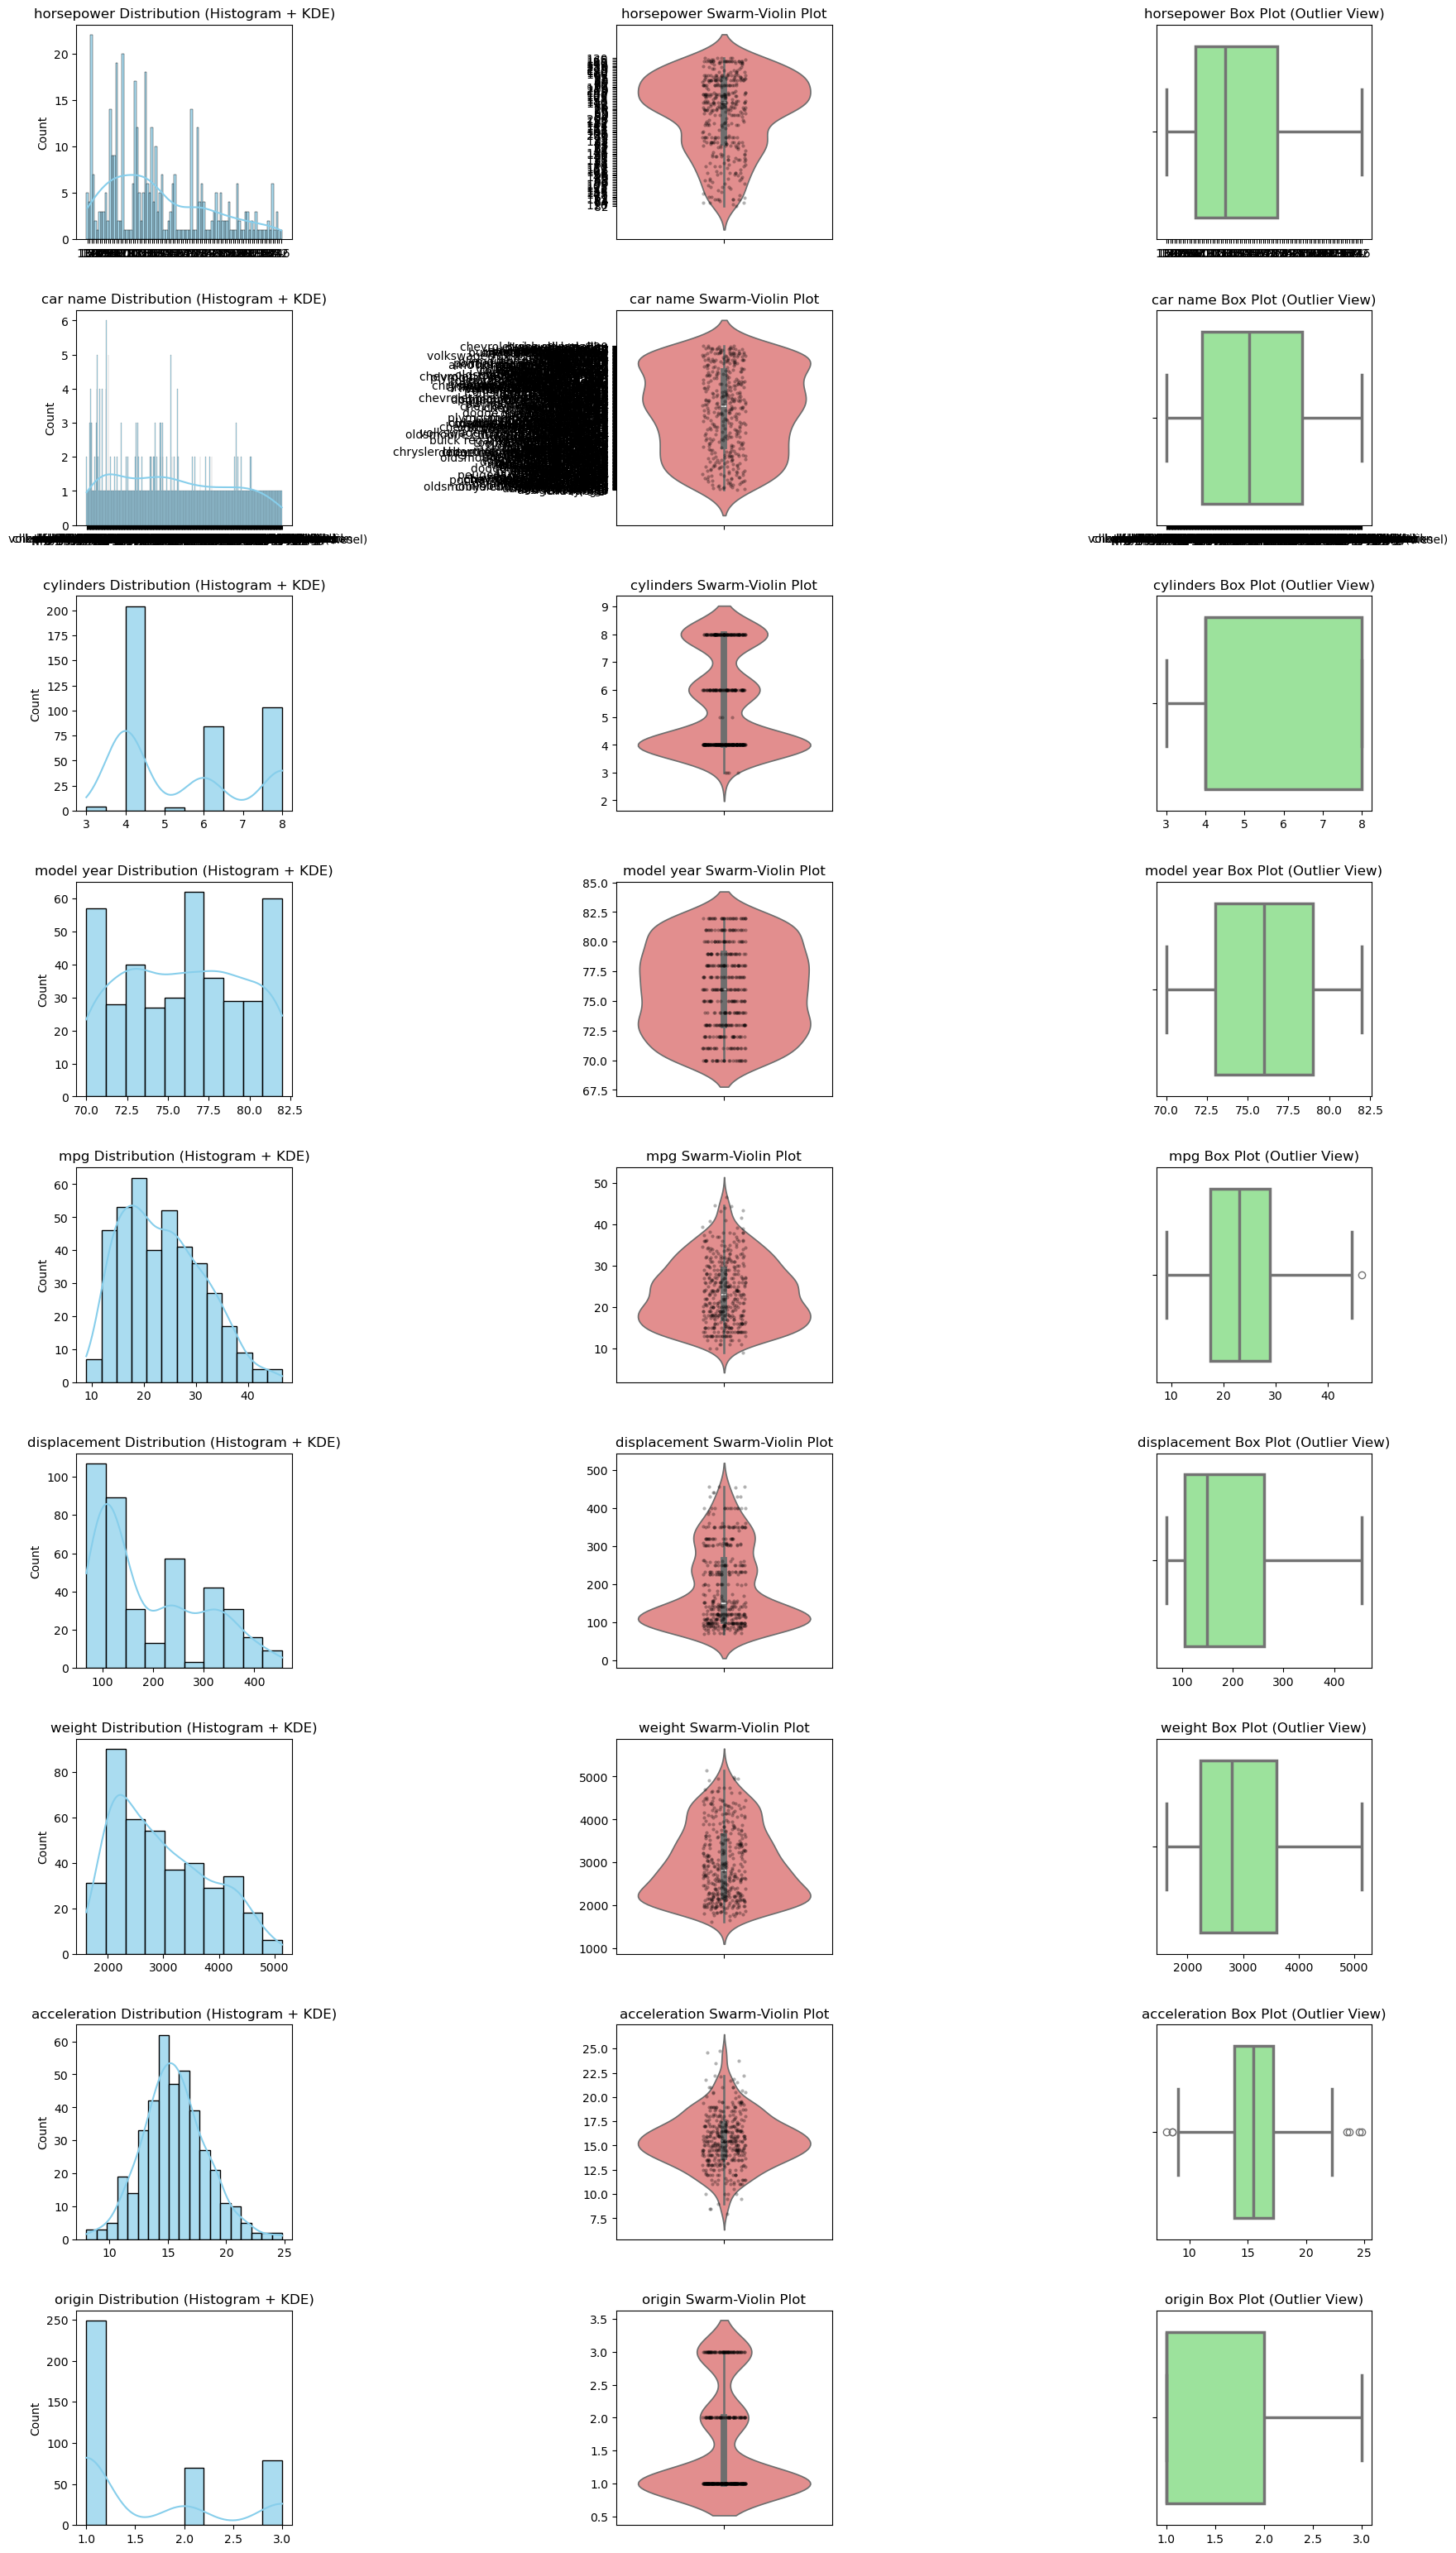

In [61]:
# ===============================================================
# Plotting Setup and Iteration
# ===============================================================

COLUMNS_TO_PLOT = df.columns
N_FEATURES = len(COLUMNS_TO_PLOT)
N_COLS = 3 # Three plots per feature (Distribution, Violin/Swarm, Box)
N_ROWS = N_FEATURES

# Set up the figure size: 18 inches wide, and 3.5 inches tall per feature row
fig = plt.figure(figsize=(18, N_ROWS * 3.5))

i = 0
for col in COLUMNS_TO_PLOT:

    # --- PLOT 1: Distribution Plot (Histogram + KDE) ---
    i += 1
    ax1 = plt.subplot(N_ROWS, N_COLS, i)
    # Using histplot (modern replacement for distplot)
    sns.histplot(data=df, x=col, kde=True, ax=ax1, color='skyblue', alpha=0.7)
    ax1.set_xlabel(None)
    ax1.set_title(f'{col} Distribution (Histogram + KDE)')

    # --- PLOT 2: Swarm-Violin Plot ---
    i += 1
    ax2 = plt.subplot(N_ROWS, N_COLS, i)
    # Plotting vertically for cleaner visualization of distribution shape
    sns.violinplot(y=df[col], ax=ax2, color='lightcoral', inner='box')
    # Use stripplot to show individual data points
    sns.stripplot(y=df[col], ax=ax2, color='k', alpha=0.3, size=3)
    ax2.set_ylabel(None)
    ax2.set_title(f'{col} Swarm-Violin Plot')

    # --- PLOT 3: Box Plot (for Outliers) ---
    i += 1
    ax3 = plt.subplot(N_ROWS, N_COLS, i)
    # Using orient='h' for horizontal box plot
    sns.boxplot(x=df[col], orient='h', ax=ax3, linewidth=2.5, color='lightgreen')
    ax3.set_xlabel(None)
    ax3.set_title(f'{col} Box Plot (Outlier View)')

# Run tight_layout once outside the loop for best results
plt.tight_layout(pad=3.0)
plt.show()

***Insights***
- Acceleration is the only distribution which is gaussian. There are few values in acceleration which lie outside the whiskers(the bars extending outwards from the box), these are fliers/outliers.
- Distributions of mpg & weight seems to be right-skewed gaussian.
- Distributions of displacement & horsepower seems to be far from gaussian.

In [62]:
# Since there are outliers let us compute them with tukeys formulae
def tukey_outliers(x):
    q1 = np.percentile(x,25)
    q3 = np.percentile(x,75)

    iqr = q3-q1

    min_range = q1 - iqr*1.5
    max_range = q3 + iqr*1.5

    outliers = x[(x<min_range) | (x>max_range)]
    return outliers

# Call function to get outliers
for col in nums:
    outliers = tukey_outliers(df[col])
    if len(outliers):
        print(f"* {col} has these tukey outliers,\n{outliers}\n")
    else:
        print(f"* {col} doesn't have any tukey outliers.\n")

* mpg has these tukey outliers,
322    46.6
Name: mpg, dtype: float64

* displacement doesn't have any tukey outliers.

* weight doesn't have any tukey outliers.

* acceleration has these tukey outliers,
7       8.5
9       8.5
11      8.0
59     23.5
299    24.8
326    23.7
394    24.6
Name: acceleration, dtype: float64

* origin doesn't have any tukey outliers.



***Insight***

Acceleration and Horsepower are the only attributes with tukey outliers and we can also notice this from the above boxplots.

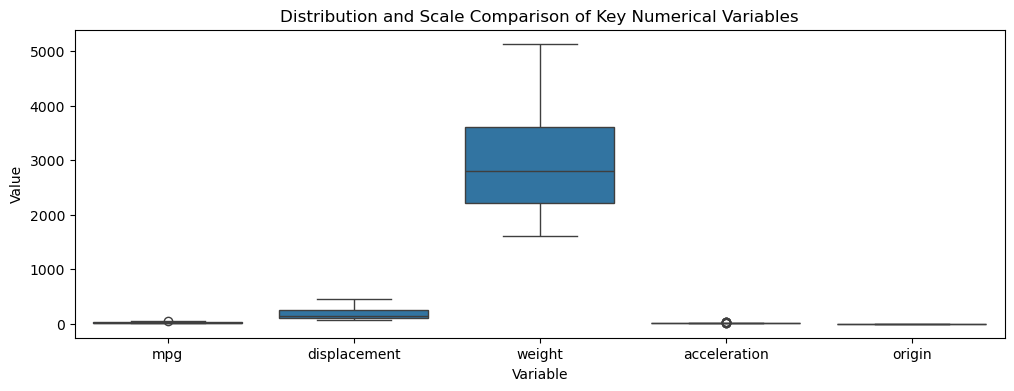

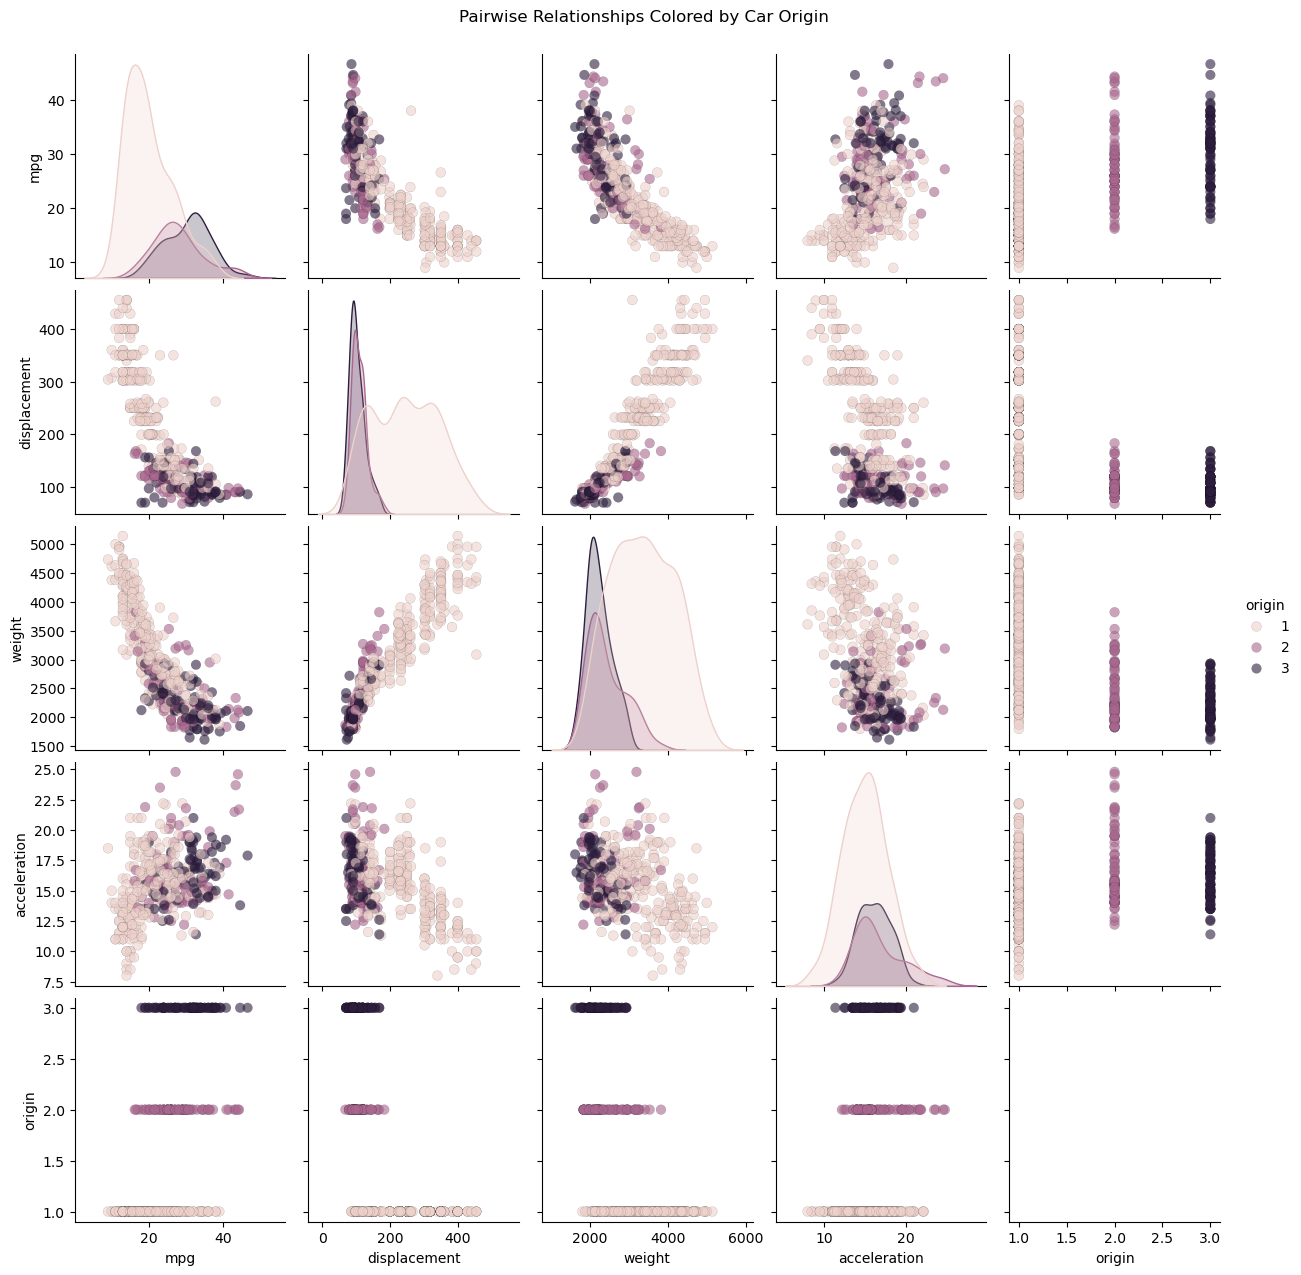

In [63]:
# Create a figure and subplot for the boxplot
fig = plt.figure(1, (12, 4))
ax = plt.subplot(1, 1, 1)

# pd.melt() transforms the wide DataFrame (multiple columns) into a long format 
# (one column for variable name, one for value), which is required for a single boxplot
# comparing all features on the y-axis. We only melt the numerical columns (`nums`).
melted_df = pd.melt(df[nums])

sns.boxplot(x="variable", y="value", data=melted_df)
plt.title("Distribution and Scale Comparison of Key Numerical Variables")
plt.xlabel("Variable")
plt.ylabel("Value")
plt.show()


# --- 2. Pair Plot for Relationship and Multivariate Distribution ---

# Annotation: The pair plot creates a grid of plots:
#   - Diagonal (diag_kind='kde'): Shows the distribution (KDE) of each variable.
#   - Off-Diagonal: Shows scatter plots between every pair of variables.
#   - hue='origin': Colors the points based on the 'origin' to check if relationships differ by region.

sns.pairplot(
    data=df, 
    vars=nums, 
    diag_kind='kde', 
    hue='origin',
    plot_kws=dict(s=50, edgecolor="k", linewidth=0.1, alpha=0.6), # Adjusted size (s) and alpha for clarity
    
)
plt.suptitle("Pairwise Relationships Colored by Car Origin", y=1.02)
plt.show()

***Insights***
- MPG is indirectly proportional to displacement, horsepower and weight (Mpg increases displacement, horsepower & weight decreases)
- MPG is directly proportional to acceleration (MPG increases with acceleration.
- As horsepower increases displacement & weight increases but acceleration decreases.
- As weight increases displacement increases but acceleration decreases.
- As acceleration increases displacement decreases.

We can conclude that all numerical attributes are related with each other.

Let us now evaluate how categorical attributes are related to numerical attributes

Generating Multivariate Relationship Plot...


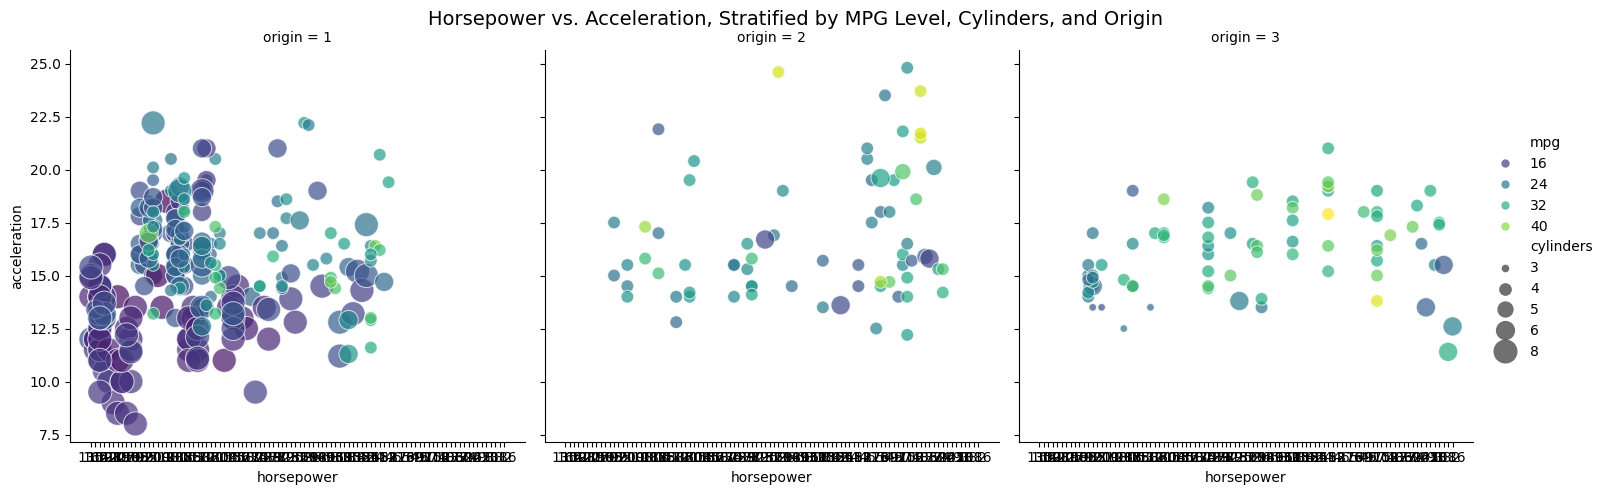


Plot successfully generated.
The analysis reveals how multiple factors influence the Horsepower/Acceleration trade-off.


In [64]:
# --- Multivariate Scatter Plot Analysis ---

# Goal: Analyze relationship between Horsepower (x) and Acceleration (y), 
# split by Origin, colored by MPG level, and sized by Cylinder count.
print("Generating Multivariate Relationship Plot...")

# sns.relplot is used to create scatter plots (kind='scatter') or line plots
sns.relplot(
    x='horsepower', 
    y='acceleration', 
    hue='mpg',        # Color of the points (Categorical: Low/Medium/High MPG)
    size='cylinders',       # Size of the points (Categorical: 4, 6, 8 cylinders)
    col='origin',           # Column split (FacetGrid: Separate plots for USA, Europe, Japan)
    data=df, 
    kind='scatter', 
    sizes=(30, 300),        # Adjust sizes range for better visual distinction
    alpha=0.7,
    palette='viridis'       # Color scheme
)

plt.subplots_adjust(top=0.9)
plt.suptitle("Horsepower vs. Acceleration, Stratified by MPG Level, Cylinders, and Origin", fontsize=14)
plt.show()

print("\nPlot successfully generated.")
print("The analysis reveals how multiple factors influence the Horsepower/Acceleration trade-off.")

***Insights***

- There is a negative relation b/w horsepower & acceleration for each region
- Vehicles with low mpg has low acceleration and high horsepower
- Vehicles with more cylinders has low acceleration and high horsepower.

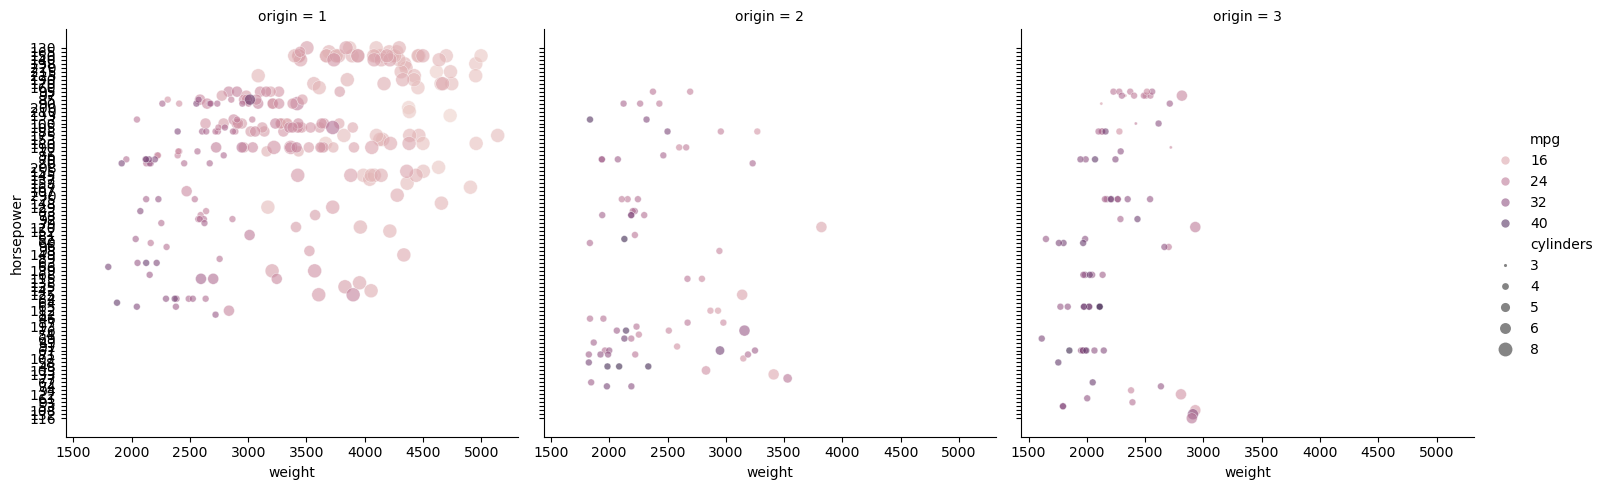

In [65]:
# analyze the relationship of weight & horsepower
#bifurcated by origin, mpg_level & cylinders in a single plot.'''

sns.relplot(x='weight', y='horsepower', hue='mpg', #style='mpg',
            size='cylinders', col='origin', data=df, kind='scatter', sizes=(5, 100), alpha=0.6)
plt.show()

variation of numerical features with origin


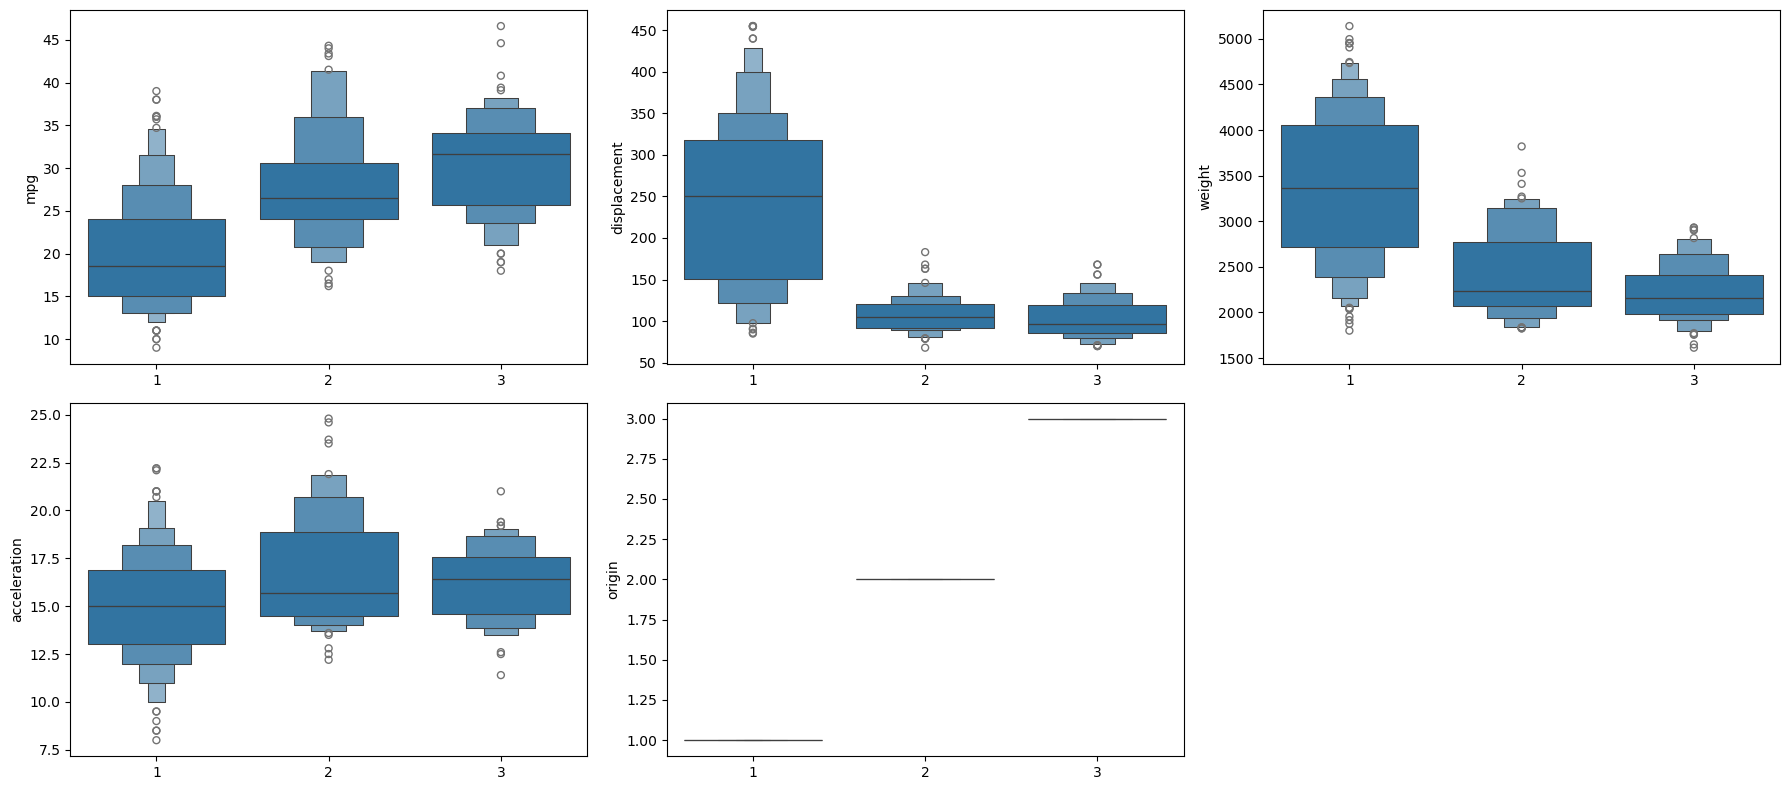

In [66]:
# relationship between numerical and categorical attributes
print('variation of numerical features with origin')

fig = plt.figure(1, (18, 8))

for idx,col in enumerate(nums):
    ax = plt.subplot(2, 3, idx+1)
    sns.boxenplot(x='origin', y=col, data=df)
    ax.set_xlabel(None)
    plt.tight_layout()

***Insights***
- vehicles of USA has less mpg on an average as compared to japan & europe.
- Vehicles of USA has more displacement, horsepower and weight as compared to japan & europe.

variation of numerical features with mpg_level


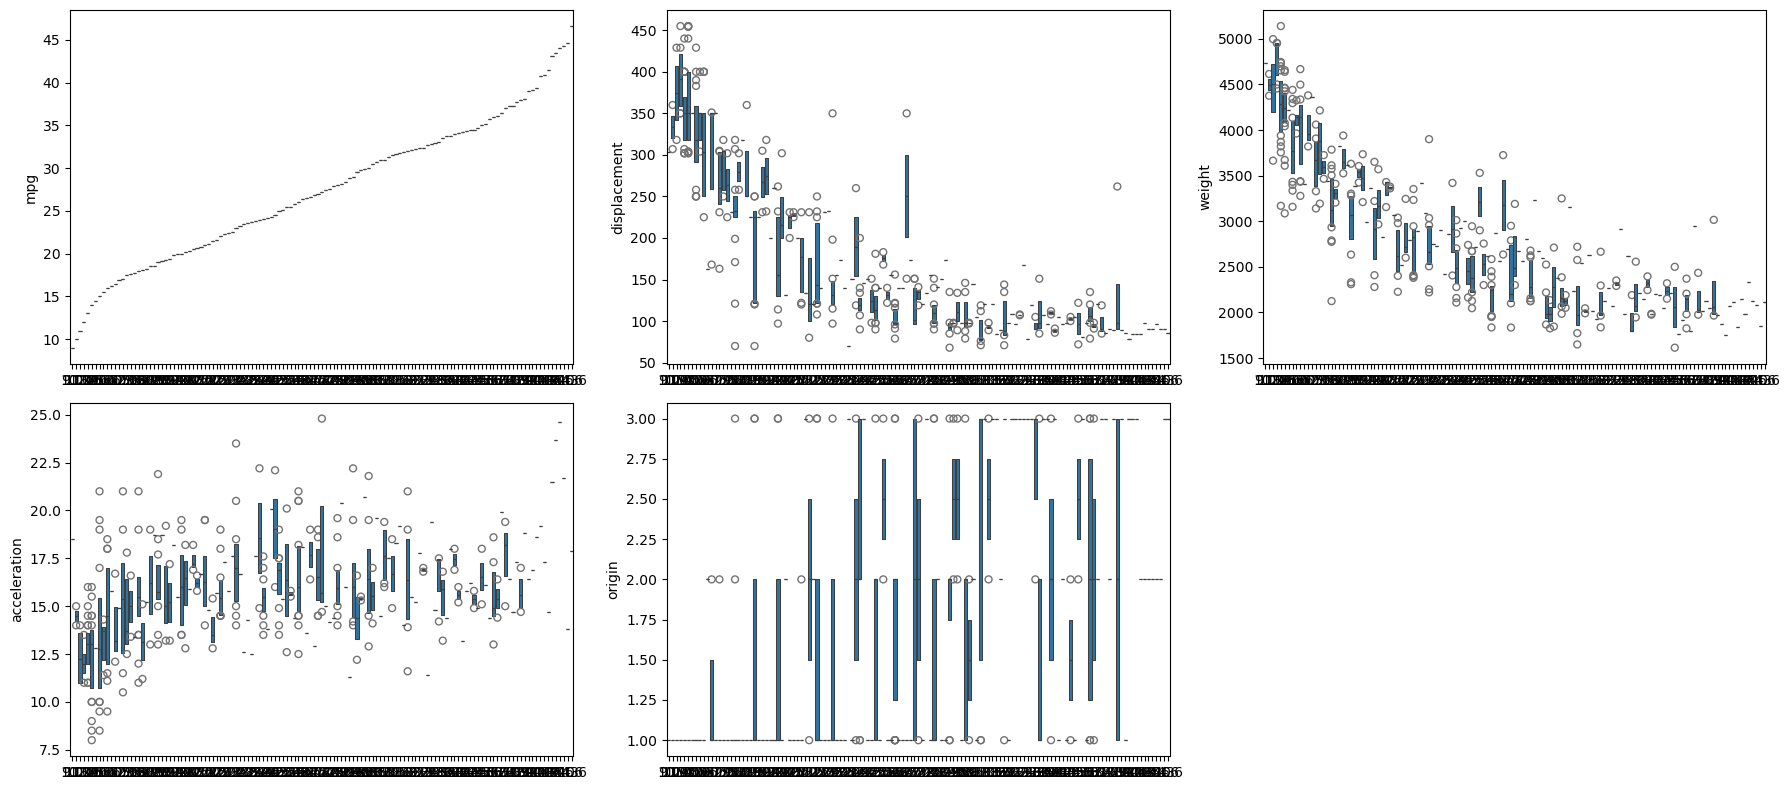

In [67]:
# Relationship using boxen plot
print('variation of numerical features with mpg_level')

fig = plt.figure(1, (18, 8))

for idx,col in enumerate(nums):
    ax = plt.subplot(2, 3, idx+1)
    sns.boxenplot(x='mpg', y=col, data=df)
    ax.set_xlabel(None)
    plt.tight_layout()

variation of numerical features with model_year


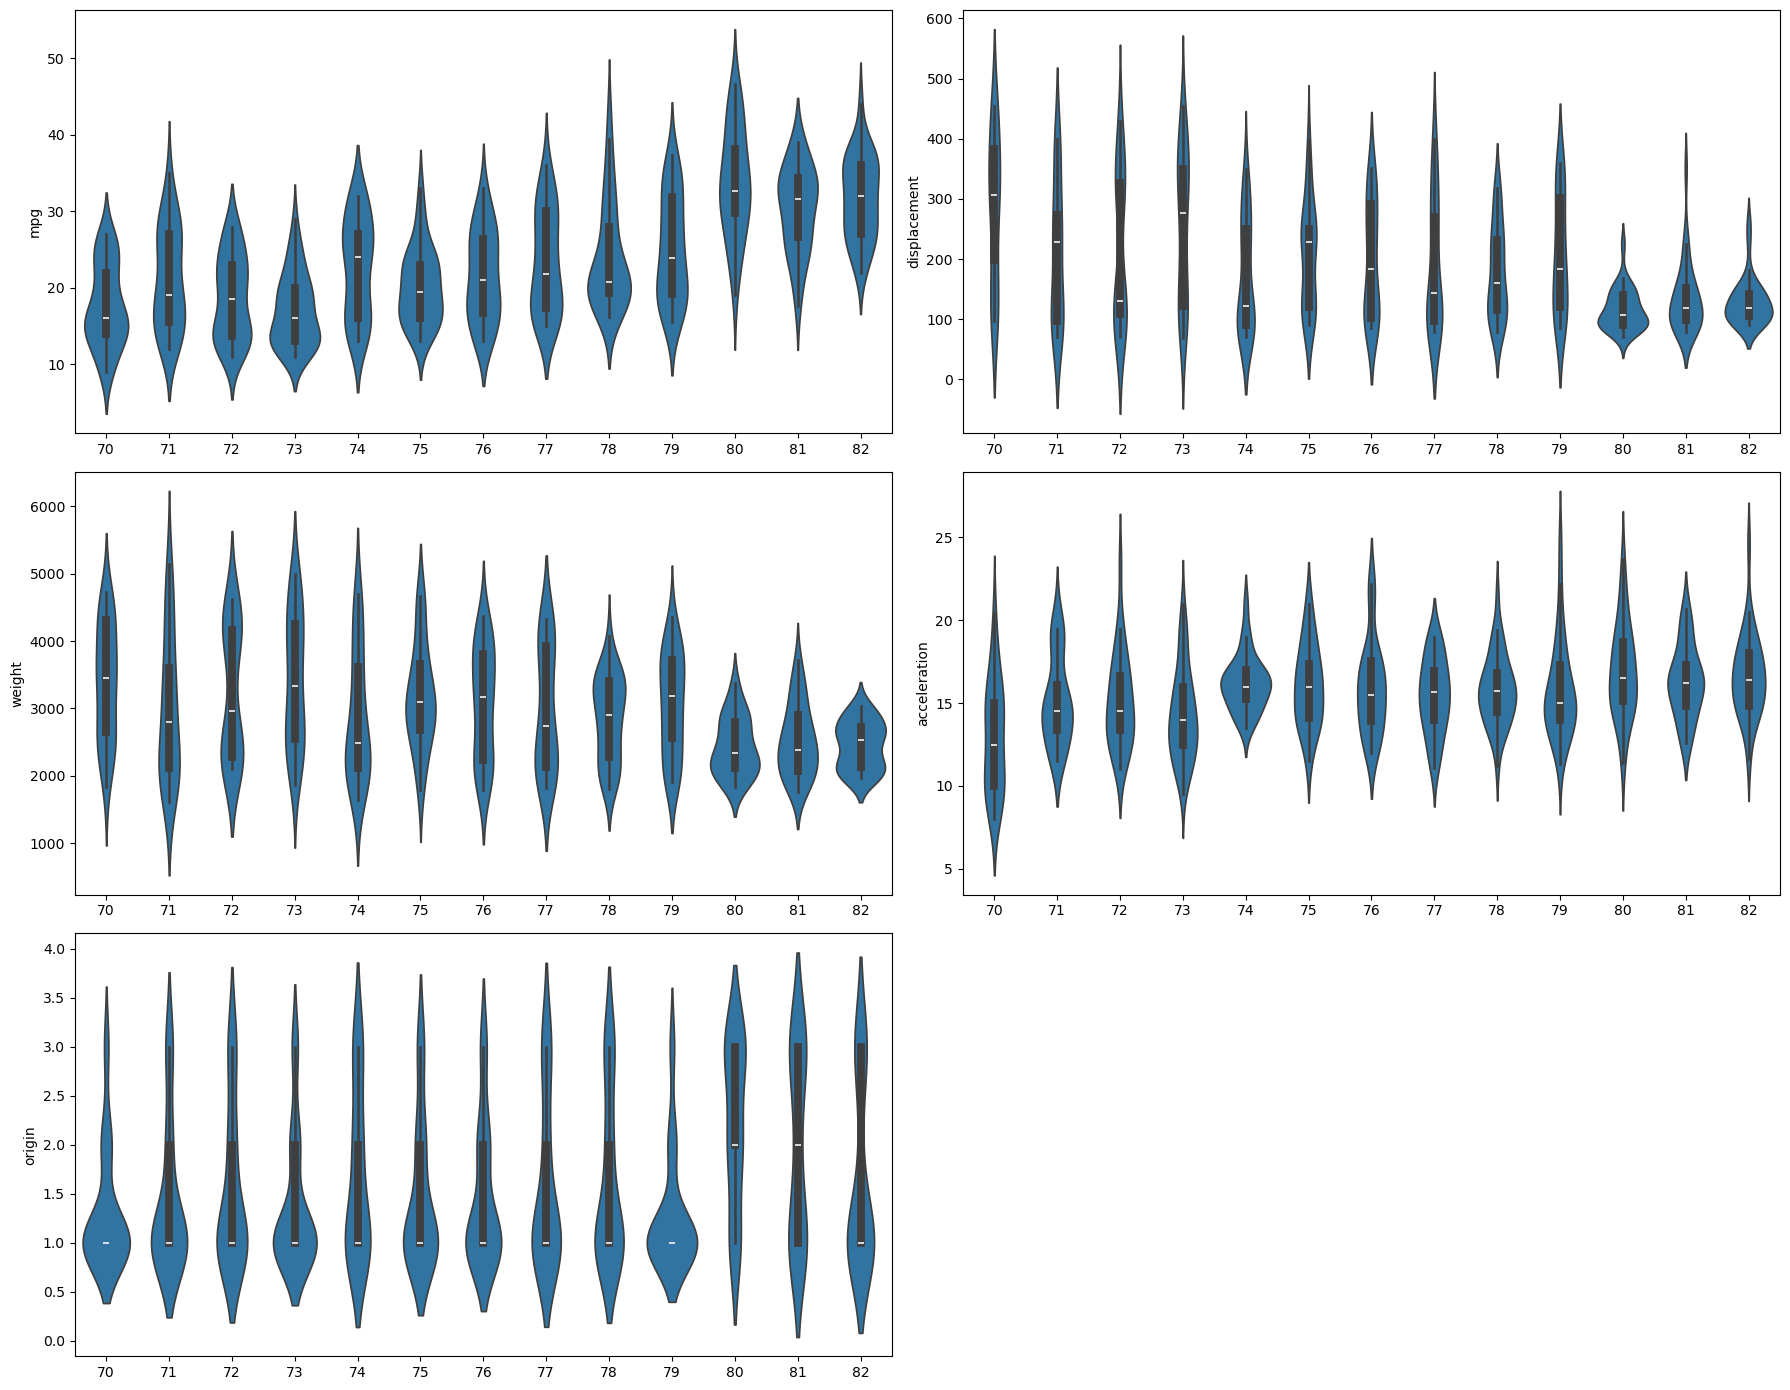

In [68]:
#Relationship using violin plot
print('variation of numerical features with model_year')

fig = plt.figure(1, (18, 14))
# fig.tight_layout()

for idx,col in enumerate(nums):
    ax = plt.subplot(3, 2, idx+1)
    sns.violinplot(x='model year', y=col, data=df)
    ax.set_xlabel(None)
    plt.tight_layout()

variation of numerical features with model_year bifurcated by origin


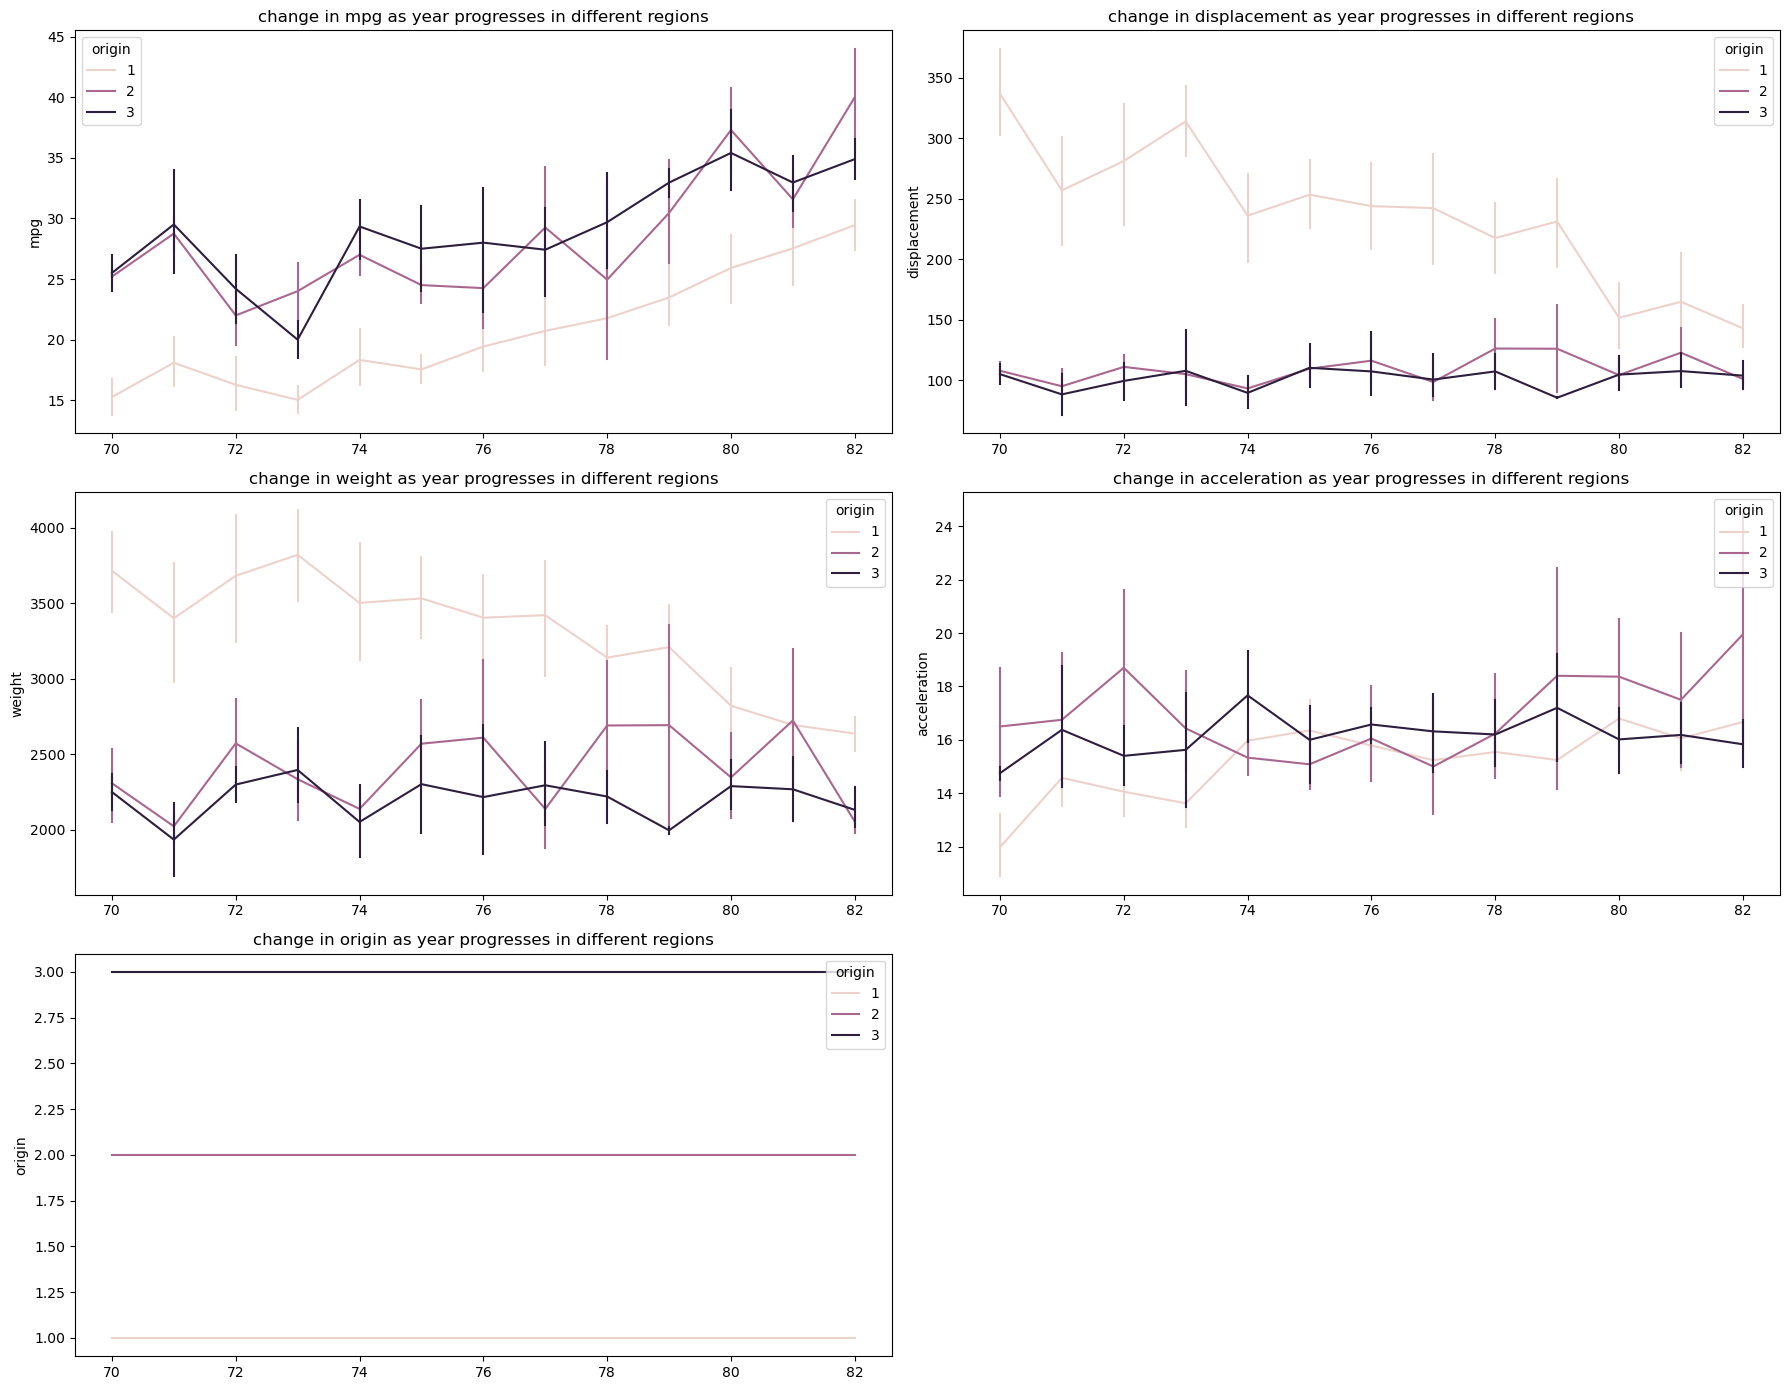

In [69]:
#Relationship using line plot
print('variation of numerical features with model_year bifurcated by origin')

fig = plt.figure(1, (18, 14))
# fig.tight_layout()

for idx,col in enumerate(nums):
    ax = plt.subplot(3, 2, idx+1)
    sns.lineplot(x="model year", y=col, hue='origin', data=df, err_style='bars')
    ax.set_title(f'change in {col} as year progresses in different regions')
    ax.set_xlabel(None)
    plt.tight_layout()

plt.show()

In [72]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
# -------------------------------------------------------
# 2. Function to compute eta squared using ANOVA
# -------------------------------------------------------
def compute_eta_squared(df, numerical, categorical):
    """
    Compute eta squared (η²) for a categorical variable
    explaining variance in a numerical variable using Type II ANOVA.
    """
    # Exclude rows where either column might be missing, although not strictly necessary 
    # for this mock data, it is good practice.
    data_clean = df.dropna(subset=[numerical, categorical])
    
    try:
        # Define the ANOVA formula: numerical ~ C(categorical)
        # C() explicitly tells statsmodels to treat the variable as categorical
        formula = f"{numerical} ~ C({categorical})"
        model = ols(formula, data=data_clean).fit()
        
        # Use Type 2 ANOVA table (preferred for unbalanced designs)
        anova_table = anova_lm(model, typ=2)

        # Eta Squared (η²) = SS_Between / SS_Total
        # In a single factor ANOVA (Type 2):
        # SS_Between = anova_table["sum_sq"][0] (Sum of Squares for the factor)
        # SS_Error (or SS_Within) = anova_table["sum_sq"][1] (Sum of Squares for Residuals)
        ss_between = anova_table["sum_sq"][0]
        ss_error = anova_table["sum_sq"][1]
        ss_total = ss_between + ss_error

        eta_sq = ss_between / ss_total
        return eta_sq
    except Exception as e:
        # Print the error for debugging purposes
        print(f"Error computing eta squared for {categorical}: {e}")
        return np.nan

# -------------------------------------------------------
# 3. Identify categorical features automatically
# -------------------------------------------------------
categorical_features = []

for col in df.columns:
    # 1. Object columns (e.g., 'origin', 'cylinders' after conversion)
    if df[col].dtype == object and df[col].nunique() < N * 0.5: # Exclude name/ID columns
        categorical_features.append(col)
    
    # 2. Numeric columns with low unique values (e.g., if 'cylinders' was still int)
    elif df[col].dtype in ['int64', 'float64']:
        if df[col].nunique() <= 15 and col != "mpg": # Exclude MPG as it is our dependent variable
             # If a numeric column is used as a category, it should be converted to string/category first
             categorical_features.append(col) 

# Remove the dependent variable ('mpg') and high cardinality keys ('car_name')
categorical_features = [c for c in categorical_features if c not in ['mpg', 'car_name']]
categorical_features = list(set(categorical_features)) # Use set to remove duplicates

print("Categorical features detected for analysis:", categorical_features)

# -------------------------------------------------------
# 4. Compute eta squared for each categorical variable
# -------------------------------------------------------
eta_results = {}

# We are testing the effect of each categorical feature on 'mpg'
for cat in categorical_features:
    eta = compute_eta_squared(df, "mpg", cat)
    eta_results[cat] = eta

# -------------------------------------------------------
# 5. Display results sorted by effect size
# -------------------------------------------------------
eta_df = pd.DataFrame.from_dict(eta_results, orient="index", columns=["eta_squared"])
eta_df = eta_df.sort_values(by="eta_squared", ascending=False)

print("\n==================================================================")
print("Eta Squared Results (Effect Size on MPG, Sorted)")
print("==================================================================")
print(eta_df.to_string(float_format="%.4f"))
print("\n")
print("Interpretation Guide:")
print("The higher the η² value, the larger the proportion of MPG variance explained by that variable.")
print("   - Large Effect: η² > 0.14")
print("   - Medium Effect: η² > 0.06")
print("   - Small Effect: η² > 0.01")
print("------------------------------------------------------------------")

NameError: name 'N' is not defined

In [ ]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm


# Convert horsepower to numeric
#df["horsepower"] = pd.to_numeric(df["horsepower"], errors="coerce")

# -------------------------------------------------------
# Function to compute eta squared
# -------------------------------------------------------
def compute_eta_squared(df, numerical, categorical):
    """
    Compute eta squared (η²) for a categorical variable
    explaining variance in a numerical variable.
    """
    try:
        formula = f"{numerical} ~ C({categorical})"
        model = ols(formula, data=df).fit()
        anova_table = anova_lm(model, typ=2)

        ss_between = anova_table["sum_sq"][0]
        ss_total = ss_between + anova_table["sum_sq"][1]

        eta_sq = ss_between / ss_total
        return eta_sq
    except Exception as e:
        return np.nan

# -------------------------------------------------------
# Identify categorical features automatically
# -------------------------------------------------------
categorical_features = []

for col in df.columns:
    if df[col].dtype == object:
        categorical_features.append(col)
    elif df[col].dtype in ['int64', 'float64']:
        # Numeric columns with low unique values behave like categorical
        if df[col].nunique() <= 15 and col != "mpg":
            categorical_features.append(col)

print("Categorical features detected:", categorical_features)

# -------------------------------------------------------
# Compute eta squared for each categorical variable
# -------------------------------------------------------
eta_results = {}

for cat in categorical_features:
    eta = compute_eta_squared(df, "mpg", cat)
    eta_results[cat] = eta

# -------------------------------------------------------
# Display results sorted by effect size
# -------------------------------------------------------
print("\n==================================================================")
print("Eta Squared Results (Effect Size on MPG, Sorted)")
print("==================================================================")
print(eta_df.to_string(float_format="%.4f"))
print("\n")
print("Interpretation Guide:")
print("The higher the η² value, the larger the proportion of MPG variance explained by that variable.")
print("   - Large Effect: η² > 0.14")
print("   - Medium Effect: η² > 0.06")
print("   - Small Effect: η² > 0.01")
print("------------------------------------------------------------------")

Categorical features detected: ['horsepower', 'car name', 'cylinders', 'model year', 'origin']

Eta Squared Results for MPG (sorted):

            eta_squared
horsepower     0.793268
cylinders      0.637242
origin         0.332864
car name            NaN
model year          NaN

Eta Squared Results (Effect Size on MPG, Sorted)
            eta_squared
horsepower       0.7933
cylinders        0.6372
origin           0.3329
car name            NaN
model year          NaN


Interpretation Guide:
The higher the η² value, the larger the proportion of MPG variance explained by that variable.
   - Large Effect: η² > 0.14
   - Medium Effect: η² > 0.06
   - Small Effect: η² > 0.01
------------------------------------------------------------------


C:\Users\jpdob\AppData\Local\Temp\ipykernel_205928\2971474780.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ss_between = anova_table["sum_sq"][0]
C:\Users\jpdob\AppData\Local\Temp\ipykernel_205928\2971474780.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ss_total = ss_between + anova_table["sum_sq"][1]
C:\Users\jpdob\AppData\Local\Temp\ipykernel_205928\2971474780.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ss_b

In [71]:
def eta_squared(data, col_cat, col_num):
    """
    Calculates the Eta Squared (η²) effect size for the impact of a 
    categorical variable (col_cat) on a numerical variable (col_num).
    
    Formula: SS_between / SS_total
    
    Args:
        data (pd.DataFrame): The input DataFrame.
        col_cat (str): The name of the categorical column (e.g., 'origin').
        col_num (str): The name of the numerical column (e.g., 'mpg').
    
    Returns:
        float: The calculated Eta Squared value.
    """
    # 1. Split the numerical column data by the categorical groups
    groups = [group[col_num] for _, group in data.groupby(col_cat)]
    
    # 2. Calculate the Grand Mean (mean of the entire numerical column)
    grand_mean = data[col_num].mean()

    # 3. Calculate Sum of Squares Between (SS_between)
    # SS_between = sum [ n_group * (mean_group - grand_mean)^2 ]
    ss_between = sum([len(g) * (g.mean() - grand_mean)**2 for g in groups])
    
    # 4. Calculate Sum of Squares Total (SS_total)
    # SS_total = sum [ (data_point - grand_mean)^2 ]
    ss_total = sum((data[col_num] - grand_mean)**2)

    # 5. Eta Squared is the ratio
    return ss_between / ss_total
# --- 3. Run and Print Eta Squared Analysis ---

print("\n===== ETA SQUARED (Effect Size: Proportion of Variance Explained) =====\n")

print("--- Effect of ORIGIN on Numerical Variables ---")
for num in cols:
    eta = eta_squared(df, 'origin', num)
    print(f"Effect of ORIGIN on {num}: {eta:.3f}")
    
print("\n--- Effect of CYLINDERS on Numerical Variables ---")
for num in cols:
    eta = eta_squared(df, 'cylinders', num)
    print(f"Effect of CYLINDERS on {num}: {eta:.3f}")

# --- Interpretation Guide ---
print("\n================ INTERPRETATION GUIDE ================")
print("Eta Squared (η²): Measures the proportion of the total variance in the")
print("numerical variable that is accounted for by the categorical grouping.")
print("   - Small Effect: η² ≈ 0.01")
print("   - Medium Effect: η² ≈ 0.06")
print("   - Large Effect: η² ≈ 0.14 or greater")
print("------------------------------------------------------")


===== ETA SQUARED (Effect Size: Proportion of Variance Explained) =====

--- Effect of ORIGIN on Numerical Variables ---


NameError: name 'cols' is not defined

In [ ]:
um] for _, group in data.groupby(col_cat)]
    grand_mean = data[col_num].mean()

    ss_between = sum([len(g) * (g.mean() - grand_mean)**2 for g in groups])
    ss_total = sum((data[col_num] - grand_mean)**2)

    return ss_between / ss_total

print("\n===== ETA SQUARED (Effect Size) =====\n")

for num in numerical_cols:
    eta = eta_squared(df, 'origin', num)
    print(f"Effect of ORIGIN on {num}: {eta:.3f}")

for num in numerical_cols:
    eta = eta_squared(df, 'cylinders', num)
    print(f"Effect of CYLINDERS on {num}: {eta:.3f}")